In [1]:
M=matrix([[1,3,7],[3,1,3],[7,3,1]])

In [2]:
W=CoxeterGroup(M)

In [3]:
W

Coxeter group over Universal Cyclotomic Field with Coxeter matrix:
[1 3 7]
[3 1 3]
[7 3 1]

In [4]:
s=W.simple_reflections()

In [5]:
s

Finite family {1: [              -1                1 -E(7)^3 - E(7)^4]
[               0                1                0]
[               0                0                1], 2: [ 1  0  0]
[ 1 -1  1]
[ 0  0  1], 3: [               1                0                0]
[               0                1                0]
[-E(7)^3 - E(7)^4                1               -1]}

In [6]:
w=s[1]*s[2]*s[3]*s[2]*s[1]

In [7]:
w.is_reflection()

True

In [8]:
L=[]
for n in range(6):
    L=L+list(W.elements_of_length(n))

In [9]:
for l in L:
    print(l.reduced_word())

[]
[1]
[2]
[3]
[1, 2]
[1, 3]
[2, 1]
[2, 3]
[3, 1]
[3, 2]
[1, 2, 1]
[1, 2, 3]
[1, 3, 1]
[1, 3, 2]
[2, 1, 3]
[2, 3, 1]
[2, 3, 2]
[3, 1, 2]
[3, 1, 3]
[3, 2, 1]
[1, 2, 1, 3]
[1, 2, 3, 1]
[1, 2, 3, 2]
[1, 3, 1, 2]
[1, 3, 1, 3]
[1, 3, 2, 1]
[2, 1, 3, 1]
[2, 1, 3, 2]
[2, 3, 1, 2]
[2, 3, 1, 3]
[2, 3, 2, 1]
[3, 1, 2, 1]
[3, 1, 2, 3]
[3, 1, 3, 1]
[3, 1, 3, 2]
[3, 2, 1, 3]
[1, 2, 1, 3, 1]
[1, 2, 1, 3, 2]
[1, 2, 3, 1, 2]
[1, 2, 3, 1, 3]
[1, 2, 3, 2, 1]
[1, 3, 1, 2, 1]
[1, 3, 1, 2, 3]
[1, 3, 1, 3, 1]
[1, 3, 1, 3, 2]
[1, 3, 2, 1, 3]
[2, 1, 3, 1, 2]
[2, 1, 3, 1, 3]
[2, 1, 3, 2, 1]
[2, 3, 1, 2, 1]
[2, 3, 1, 2, 3]
[2, 3, 1, 3, 1]
[2, 3, 1, 3, 2]
[2, 3, 2, 1, 3]
[3, 1, 2, 1, 3]
[3, 1, 2, 3, 1]
[3, 1, 2, 3, 2]
[3, 1, 3, 1, 2]
[3, 1, 3, 1, 3]
[3, 1, 3, 2, 1]
[3, 2, 1, 3, 1]
[3, 2, 1, 3, 2]


In [10]:
w^2

[1 0 0]
[0 1 0]
[0 0 1]

In [11]:
def triangleFinite(w,m1,m2,m3):
    if w^m1.is_one() or w^m2.is_one() or w^m3.is_one():
        return True
    else:
        return False

In [12]:
triangleFinite(w,3,3,7)

True

In [14]:
r1=s[1]*s[3]*s[1]
r2=s[3]*s[2]*s[3]

In [15]:
triangleFinite(r1*r2,3,3,7)

True

In [16]:
CG=W.cayley_graph(elements=L)

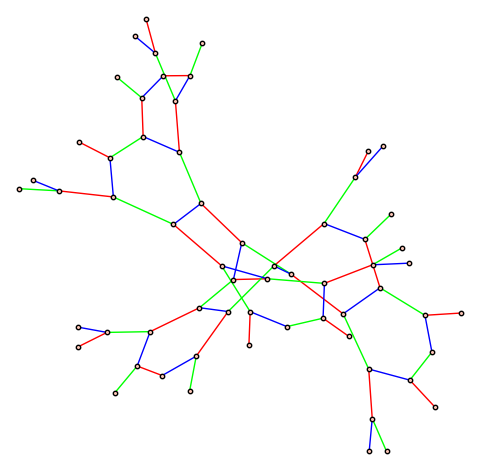

In [17]:
CG.to_undirected().plot(vertex_labels=False,color_by_label=True,vertex_size=10)

In [18]:
def genTriGroup(m1,m2,m3):
    M=matrix([[1,m1,m2],[m1,1,m3],[m2,m3,1]])
    W=CoxeterGroup(M)
    return W

In [19]:
genTriGroup(3,7,3)

Coxeter group over Universal Cyclotomic Field with Coxeter matrix:
[1 3 7]
[3 1 3]
[7 3 1]

In [24]:
U=["a","s","t"]

In [64]:
States = []
for u in list(powerset(U)):
    States.append(tuple(u))

In [74]:
States

[(),
 ('a',),
 ('s',),
 ('a', 's'),
 ('t',),
 ('a', 't'),
 ('s', 't'),
 ('a', 's', 't')]

In [71]:
FSA=Automaton()

In [72]:
FSA.add_states(States)

In [73]:
FSA

Automaton with 8 states

In [92]:
FSA.add_transition(States[0],States[1],"a")

Transition from () to ('a',): 'a'|-

In [93]:
FSA.add_transition(States[0],States[2],"s")

Transition from () to ('s',): 's'|-

In [94]:
FSA.add_transition(States[0],States[4],"t")

Transition from () to ('t',): 't'|-

In [95]:
FSA.add_transition(States[0],States[3],"as")

Transition from () to ('a', 's'): 'as'|-

In [96]:
FSA.add_transition(States[0],States[3],"sa")

Transition from () to ('a', 's'): 'sa'|-

In [97]:
FSA.add_transition(States[0],States[5],"at")

Transition from () to ('a', 't'): 'at'|-

In [98]:
FSA.add_transition(States[0],States[5],"ta")

Transition from () to ('a', 't'): 'ta'|-

In [99]:
FSA.add_transition(States[2],States[4],"t")

Transition from ('s',) to ('t',): 't'|-

In [100]:
FSA.add_transition(States[4],States[2],"s")

Transition from ('t',) to ('s',): 's'|-

In [101]:
FSA.add_transition(States[4],States[3],"as")

Transition from ('t',) to ('a', 's'): 'as'|-

In [102]:
FSA.add_transition(States[4],States[3],"sa")

Transition from ('t',) to ('a', 's'): 'sa'|-

In [103]:
FSA.add_transition(States[2],States[5],"at")

Transition from ('s',) to ('a', 't'): 'at'|-

In [104]:
FSA.add_transition(States[2],States[5],"ta")

Transition from ('s',) to ('a', 't'): 'ta'|-

In [120]:
Min

Automaton with 1 state

In [125]:
FSA.state(FSA.states()[0]).is_initial=True

In [126]:
FSA.initial_states()

[()]

In [127]:
for s in FSA.states():
    FSA.state(s).is_final=True

In [131]:
list(FSA.language(max_length=5))

[[],
 ['a'],
 ['s'],
 ['t'],
 ['as'],
 ['sa'],
 ['at'],
 ['ta'],
 ['s', 't'],
 ['s', 'at'],
 ['s', 'ta'],
 ['t', 's'],
 ['t', 'as'],
 ['t', 's'],
 ['t', 'sa'],
 ['s', 't', 's'],
 ['s', 't', 'as'],
 ['s', 't', 's'],
 ['s', 't', 'sa'],
 ['t', 's', 't'],
 ['t', 's', 'at'],
 ['t', 's', 'ta'],
 ['s', 't', 's', 't'],
 ['s', 't', 's', 'at'],
 ['s', 't', 's', 'ta'],
 ['t', 's', 't', 's'],
 ['t', 's', 't', 'as'],
 ['t', 's', 't', 's'],
 ['t', 's', 't', 'sa'],
 ['s', 't', 's', 't', 's'],
 ['s', 't', 's', 't', 'as'],
 ['s', 't', 's', 't', 's'],
 ['s', 't', 's', 't', 'sa'],
 ['t', 's', 't', 's', 't'],
 ['t', 's', 't', 's', 'at'],
 ['t', 's', 't', 's', 'ta']]

In [132]:
Min=FSA.minimization()

In [133]:
Min

Automaton with 5 states

In [ ]:
list(Min.language(max_length=5))

[frozenset({frozenset({()}),
            frozenset({(), ('t',)}),
            frozenset({(), ('s',)}),
            frozenset({(),
                       ('a',),
                       ('a', 's'),
                       ('a', 's', 't'),
                       ('a', 't'),
                       ('s',),
                       ('s', 't'),
                       ('t',)})}),
 frozenset({frozenset({(),
                       ('a',),
                       ('a', 's'),
                       ('a', 's', 't'),
                       ('a', 't'),
                       ('s',),
                       ('s', 't'),
                       ('t',)})}),
 frozenset({frozenset({(), ('t',)}),
            frozenset({(),
                       ('a',),
                       ('a', 's'),
                       ('a', 's', 't'),
                       ('a', 't'),
                       ('s',),
                       ('s', 't'),
                       ('t',)})}),
 frozenset({frozenset({(), ('s',)}),
            froz